Desarollar un claasificacion para la DB iris dataset con particion 70/30 con clasificadores LDA y k-NN, decision tree. Mostrar fronteras de decision. Mostrar metricas

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix, 
    mean_absolute_error, mean_squared_error, r2_score)

from sklearn.datasets import fetch_california_housing, load_iris, load_digits, load_wine, load_breast_cancer, fetch_openml
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, FunctionTransformer, StandardScaler
from sklearn.model_selection import cross_validate, KFold, train_test_split

In [2]:
# Cargar Iris y seleccionar dos variables para visualizar fronteras en 2D
iris = load_iris()
X = iris.data[:, [2, 3]]  # longitud y ancho del pétalo
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

modelos = {
    "LDA": Pipeline([
        ("escalado", StandardScaler()),
        ("modelo", LinearDiscriminantAnalysis())
    ]),
    "k-NN": Pipeline([
        ("escalado", StandardScaler()),
        ("modelo", KNeighborsClassifier(n_neighbors=5))
    ]),
    "Árbol de decisión": DecisionTreeClassifier(
        max_depth=4, random_state=42
    )
}

In [3]:
resultados = []

# Entrenamiento y métricas
for nombre, modelo in modelos.items():
    modelo.fit(X_train, y_train)
    predicciones = modelo.predict(X_test)

    resultados.append({
        "Clasificador": nombre,
        "Exactitud": accuracy_score(y_test, predicciones),
        "Precisión": precision_score(y_test, predicciones, average="macro"),
        "Recall": recall_score(y_test, predicciones, average="macro"),
        "F1": f1_score(y_test, predicciones, average="macro")
    })

    print(f"\n{'=' * 50}\n{nombre}\n{'=' * 50}")
    print(classification_report(
        y_test,
        predicciones,
        target_names=iris.target_names
    ))
    print("Matriz de confusión:")
    print(confusion_matrix(y_test, predicciones))

metricas = pd.DataFrame(resultados).set_index("Clasificador")
display(metricas.round(3))

# Fronteras de decisión
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 400),
    np.linspace(y_min, y_max, 400)
)


LDA
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.82      0.93      0.88        15
   virginica       0.92      0.80      0.86        15

    accuracy                           0.91        45
   macro avg       0.92      0.91      0.91        45
weighted avg       0.92      0.91      0.91        45

Matriz de confusión:
[[15  0  0]
 [ 0 14  1]
 [ 0  3 12]]

k-NN
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.82      0.93      0.88        15
   virginica       0.92      0.80      0.86        15

    accuracy                           0.91        45
   macro avg       0.92      0.91      0.91        45
weighted avg       0.92      0.91      0.91        45

Matriz de confusión:
[[15  0  0]
 [ 0 14  1]
 [ 0  3 12]]

Árbol de decisión
              precision    recall  f1-score   support

      setosa       1.00      1.00    

,Exactitud,Precisión,Recall,F1
Clasificador,,,,
LDA,0.911,0.916,0.911,0.911
k-NN,0.911,0.916,0.911,0.911
Árbol de decisión,0.933,0.935,0.933,0.933


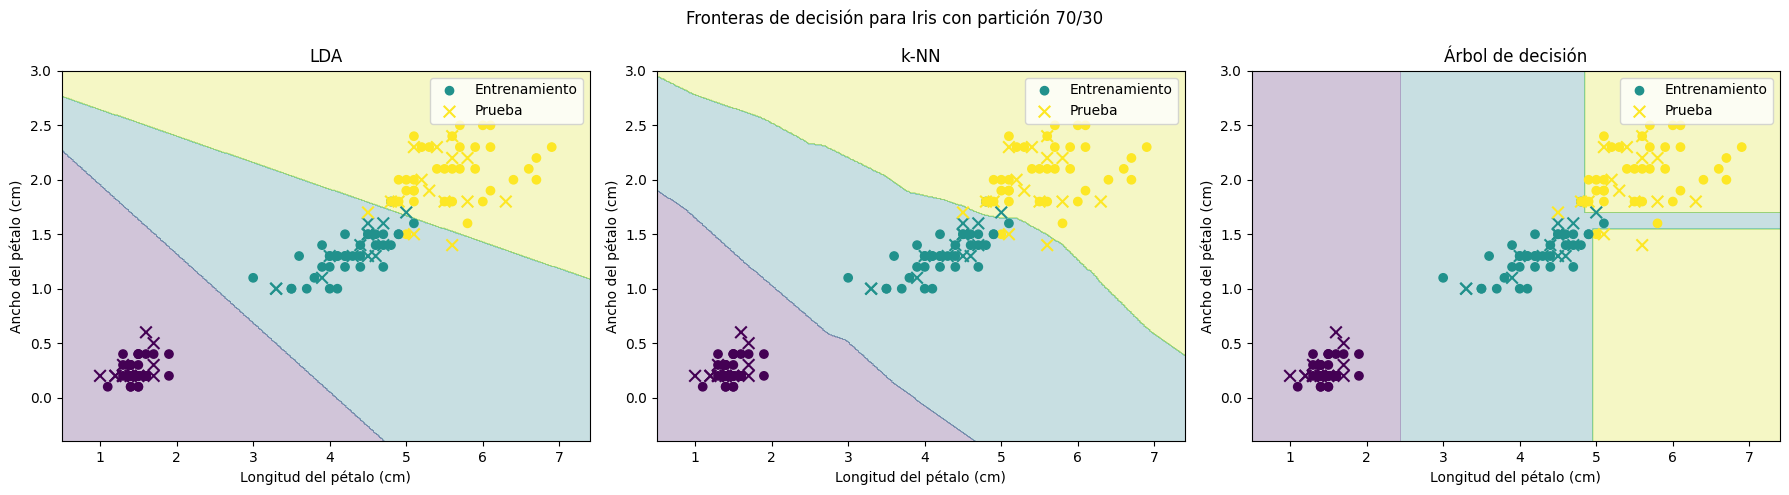

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (nombre, modelo) in zip(axes, modelos.items()):
    Z = modelo.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.25, cmap="viridis")
    ax.scatter(
        X_train[:, 0], X_train[:, 1],
        c=y_train, cmap="viridis",
        marker="o", label="Entrenamiento"
    )
    ax.scatter(
        X_test[:, 0], X_test[:, 1],
        c=y_test, cmap="viridis",
        marker="x", s=70, label="Prueba"
    )

    ax.set_title(nombre)
    ax.set_xlabel("Longitud del pétalo (cm)")
    ax.set_ylabel("Ancho del pétalo (cm)")
    ax.legend()

plt.suptitle("Fronteras de decisión para Iris con partición 70/30")
plt.tight_layout()
plt.show()

Probar clasficadores con sobre-ajuste y sub ajuste, Aumentar orden de los modelos sin justificacion (k=7 en knn), con la misma db iris

c:\Users\natal\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,Exactitud entrenamiento,Exactitud prueba,Precisión prueba,Recall prueba,F1 prueba
Clasificador,,,,,
"k-NN (subajuste, k=30)",0.981,0.911,0.916,0.911,0.911
k-NN (k=7),0.981,0.911,0.916,0.911,0.911
"k-NN (sobreajuste, k=1)",0.990,1.000,1.000,1.000,1.000
"Árbol (subajuste, profundidad=1)",0.667,0.667,0.500,0.667,0.556
Árbol (profundidad=4),0.981,0.933,0.935,0.933,0.933
"Árbol (sobreajuste, sin límite)",0.990,0.933,0.935,0.933,0.933


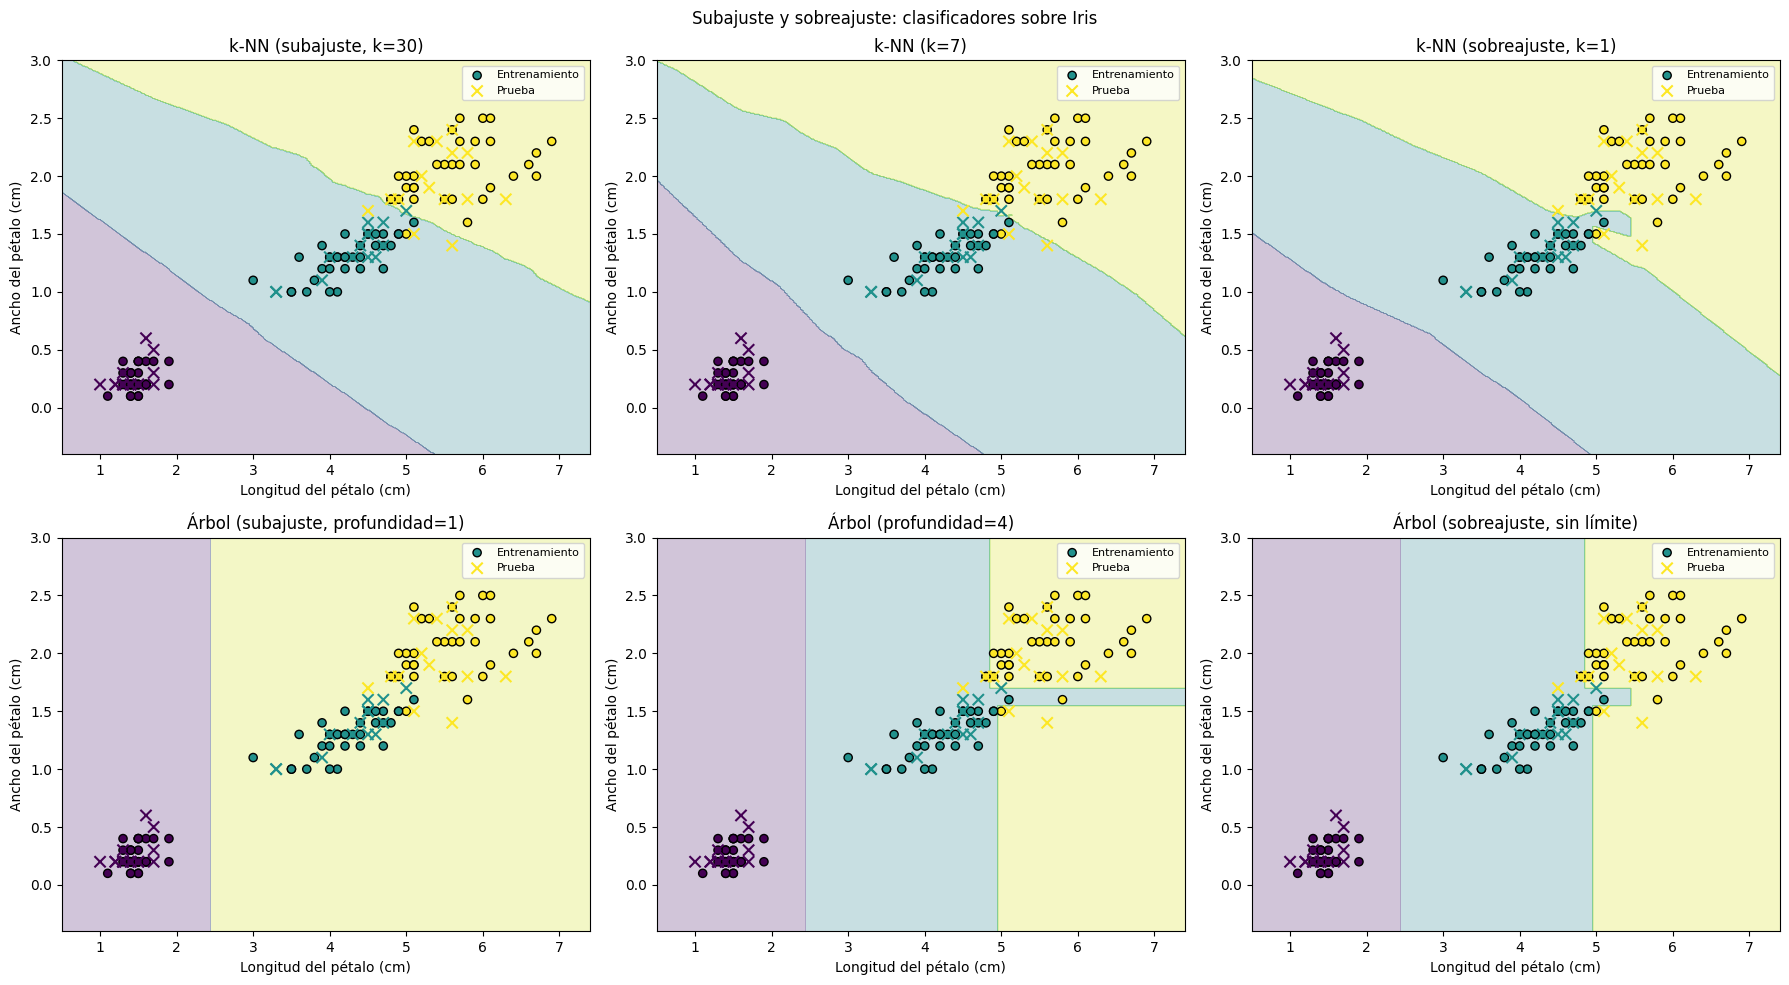

In [5]:
# Comparación de subajuste, ajuste adecuado y sobreajuste en Iris
modelos_ajuste = {
    "k-NN (subajuste, k=30)": Pipeline([
        ("escalado", StandardScaler()),
        ("modelo", KNeighborsClassifier(n_neighbors=30))
    ]),
    "k-NN (k=7)": Pipeline([
        ("escalado", StandardScaler()),
        ("modelo", KNeighborsClassifier(n_neighbors=7))
    ]),
    "k-NN (sobreajuste, k=1)": Pipeline([
        ("escalado", StandardScaler()),
        ("modelo", KNeighborsClassifier(n_neighbors=1))
    ]),
    "Árbol (subajuste, profundidad=1)": DecisionTreeClassifier(
        max_depth=1, random_state=42
    ),
    "Árbol (profundidad=4)": DecisionTreeClassifier(
        max_depth=4, random_state=42
    ),
    "Árbol (sobreajuste, sin límite)": DecisionTreeClassifier(
        max_depth=None, random_state=42
    )
}

resultados_ajuste = []

for nombre, modelo in modelos_ajuste.items():
    modelo.fit(X_train, y_train)

    pred_train = modelo.predict(X_train)
    pred_test = modelo.predict(X_test)

    resultados_ajuste.append({
        "Clasificador": nombre,
        "Exactitud entrenamiento": accuracy_score(y_train, pred_train),
        "Exactitud prueba": accuracy_score(y_test, pred_test),
        "Precisión prueba": precision_score(
            y_test, pred_test, average="macro"
        ),
        "Recall prueba": recall_score(
            y_test, pred_test, average="macro"
        ),
        "F1 prueba": f1_score(
            y_test, pred_test, average="macro"
        )
    })

metricas_ajuste = pd.DataFrame(resultados_ajuste).set_index("Clasificador")
display(metricas_ajuste.round(3))

# Fronteras de decisión
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

for ax, (nombre, modelo) in zip(axes, modelos_ajuste.items()):
    Z_ajuste = modelo.predict(
        np.c_[xx.ravel(), yy.ravel()]
    ).reshape(xx.shape)

    ax.contourf(
        xx, yy, Z_ajuste,
        alpha=0.25,
        cmap="viridis"
    )
    ax.scatter(
        X_train[:, 0], X_train[:, 1],
        c=y_train,
        cmap="viridis",
        edgecolor="black",
        s=35,
        label="Entrenamiento"
    )
    ax.scatter(
        X_test[:, 0], X_test[:, 1],
        c=y_test,
        cmap="viridis",
        marker="x",
        s=65,
        label="Prueba"
    )

    ax.set_title(nombre)
    ax.set_xlabel("Longitud del pétalo (cm)")
    ax.set_ylabel("Ancho del pétalo (cm)")
    ax.legend(fontsize=8)

plt.suptitle("Subajuste y sobreajuste: clasificadores sobre Iris")
plt.tight_layout()
plt.show()

Probar clasficadores con sobre-ajuste y sub ajuste, cross validation (50/50), (40/60)

,Partición,Clasificador,Exactitud entrenamiento,Exactitud prueba,F1 prueba,Exactitud CV media,Exactitud CV desv.,F1 CV medio,F1 CV desv.
1,50% entrenamiento / 50% prueba,k-NN (k=7),0.973,0.947,0.947,0.973,0.033,0.973,0.033
0,50% entrenamiento / 50% prueba,"k-NN (subajuste, k=30)",0.987,0.933,0.933,0.987,0.027,0.987,0.027
2,50% entrenamiento / 50% prueba,"k-NN (sobreajuste, k=1)",1.000,0.933,0.933,0.933,0.042,0.932,0.044
5,50% entrenamiento / 50% prueba,"Árbol (sobreajuste, sin límite)",1.000,0.893,0.892,0.960,0.033,0.960,0.033
4,50% entrenamiento / 50% prueba,Árbol (profundidad=4),0.987,0.880,0.878,0.960,0.033,0.960,0.033
3,50% entrenamiento / 50% prueba,"Árbol (subajuste, profundidad=1)",0.667,0.667,0.556,0.667,0.000,0.556,0.000
8,60% entrenamiento / 40% prueba,"k-NN (sobreajuste, k=1)",0.989,1.000,1.000,0.933,0.082,0.928,0.092
10,60% entrenamiento / 40% prueba,Árbol (profundidad=4),0.978,0.950,0.950,0.922,0.044,0.920,0.046
11,60% entrenamiento / 40% prueba,"Árbol (sobreajuste, sin límite)",0.989,0.950,0.950,0.922,0.044,0.920,0.046
6,60% entrenamiento / 40% prueba,"k-NN (subajuste, k=30)",0.978,0.933,0.933,0.978,0.027,0.978,0.027


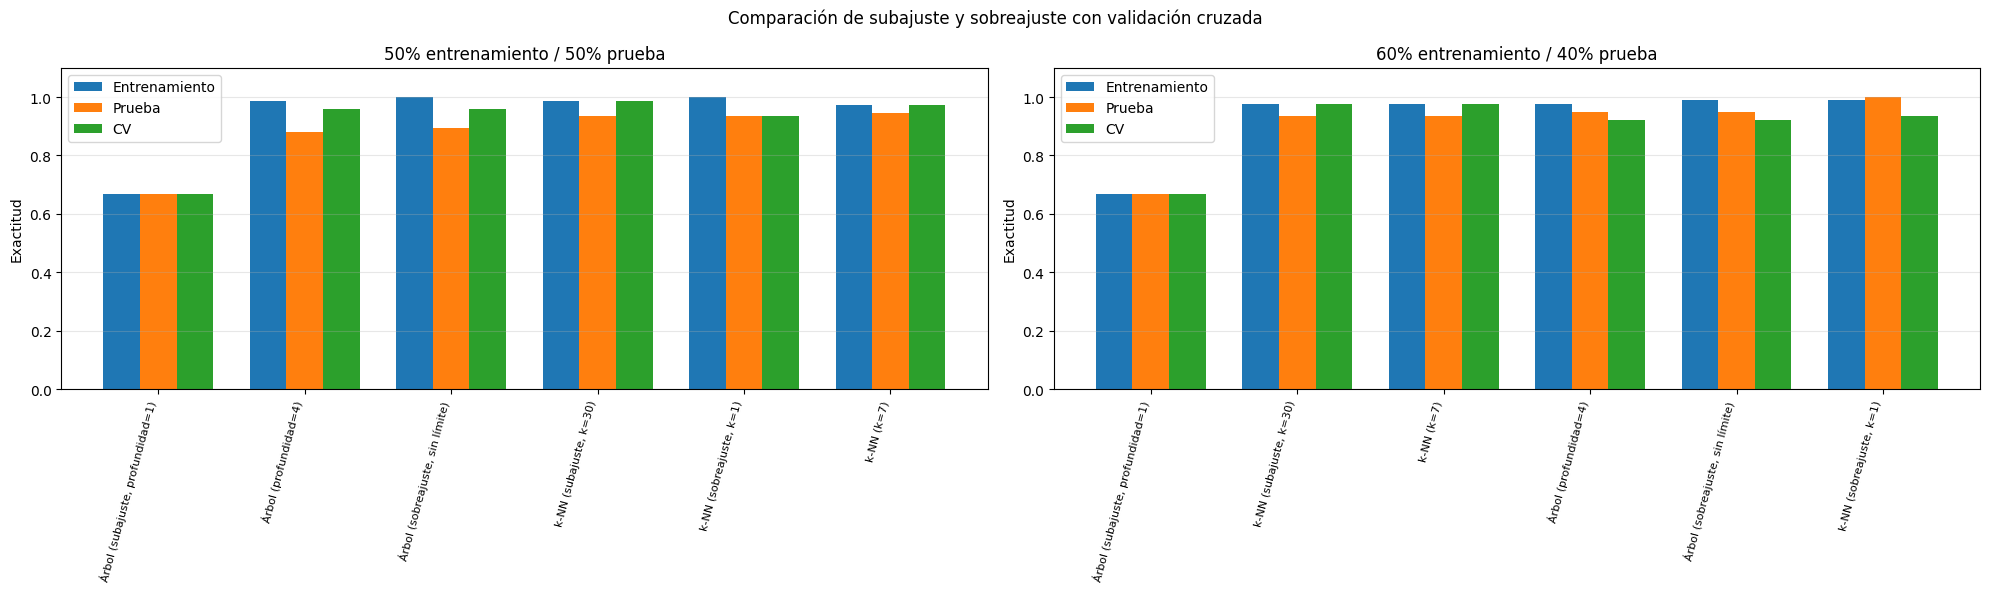

In [6]:
# Comparación de subajuste y sobreajuste con particiones 50/50 y 40/60
# Se reutilizan X, y y modelos_ajuste definidos anteriormente.

from sklearn.model_selection import cross_validate


particiones = {
    "50% entrenamiento / 50% prueba": 0.50,
    "60% entrenamiento / 40% prueba": 0.40
}

resultados_cv = []

for nombre_particion, test_size in particiones.items():
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y,
        test_size=test_size,
        random_state=42,
        stratify=y
    )

    for nombre, modelo in modelos_ajuste.items():
        modelo.fit(X_tr, y_tr)

        pred_tr = modelo.predict(X_tr)
        pred_te = modelo.predict(X_te)

        cv_resultado = cross_validate(
            modelo,
            X_tr,
            y_tr,
            cv=5,
            scoring={
                "accuracy": "accuracy",
                "f1_macro": "f1_macro"
            }
        )

        resultados_cv.append({
            "Partición": nombre_particion,
            "Clasificador": nombre,
            "Exactitud entrenamiento": accuracy_score(y_tr, pred_tr),
            "Exactitud prueba": accuracy_score(y_te, pred_te),
            "F1 prueba": f1_score(y_te, pred_te, average="macro"),
            "Exactitud CV media": cv_resultado["test_accuracy"].mean(),
            "Exactitud CV desv.": cv_resultado["test_accuracy"].std(),
            "F1 CV medio": cv_resultado["test_f1_macro"].mean(),
            "F1 CV desv.": cv_resultado["test_f1_macro"].std()
        })

metricas_cv = pd.DataFrame(resultados_cv)

display(
    metricas_cv.sort_values(
        ["Partición", "Exactitud prueba"],
        ascending=[True, False]
    ).round(3)
)

# Visualización de exactitud en entrenamiento, prueba y validación cruzada
fig, axes = plt.subplots(1, 2, figsize=(20, 6))

for ax, (particion, datos) in zip(
    axes, metricas_cv.groupby("Partición")
):
    datos = datos.sort_values("Exactitud prueba")

    x_pos = np.arange(len(datos))
    ancho = 0.25

    ax.bar(
        x_pos - ancho,
        datos["Exactitud entrenamiento"],
        width=ancho,
        label="Entrenamiento"
    )
    ax.bar(
        x_pos,
        datos["Exactitud prueba"],
        width=ancho,
        label="Prueba"
    )
    ax.bar(
        x_pos + ancho,
        datos["Exactitud CV media"],
        width=ancho,
        label="CV"
    )

    ax.set_title(particion)
    ax.set_ylabel("Exactitud")
    ax.set_ylim(0, 1.1)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(
        datos["Clasificador"],
        rotation=75,
        ha="right",
        fontsize=8
    )
    ax.grid(axis="y", alpha=0.3)
    ax.legend()

plt.suptitle(
    "Comparación de subajuste y sobreajuste con validación cruzada"
)
plt.tight_layout()
plt.show()

Desarrollar una comparacion para diferentes modelos de regresion: lineal, polinomial, logaritmica, con la DB BostonHousing/California Housibg. Mostrar metricas y lineas de estimacion. Incluir cross-validationn

,MAE prueba,RMSE prueba,R2 prueba,MAE CV,RMSE CV,R2 CV
Modelo,,,,,,
Regresión lineal,0.6232,0.8317,0.4729,0.6263,0.8373,0.4732
Regresión polinomial,0.6217,0.8281,0.4775,0.6252,0.8337,0.4777
Regresión logarítmica,0.6462,0.8492,0.4506,0.6519,0.8568,0.4485


c:\Users\natal\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\natal\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
c:\Users\natal\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but FunctionTransformer was fitted with feature names
  warnings.warn(


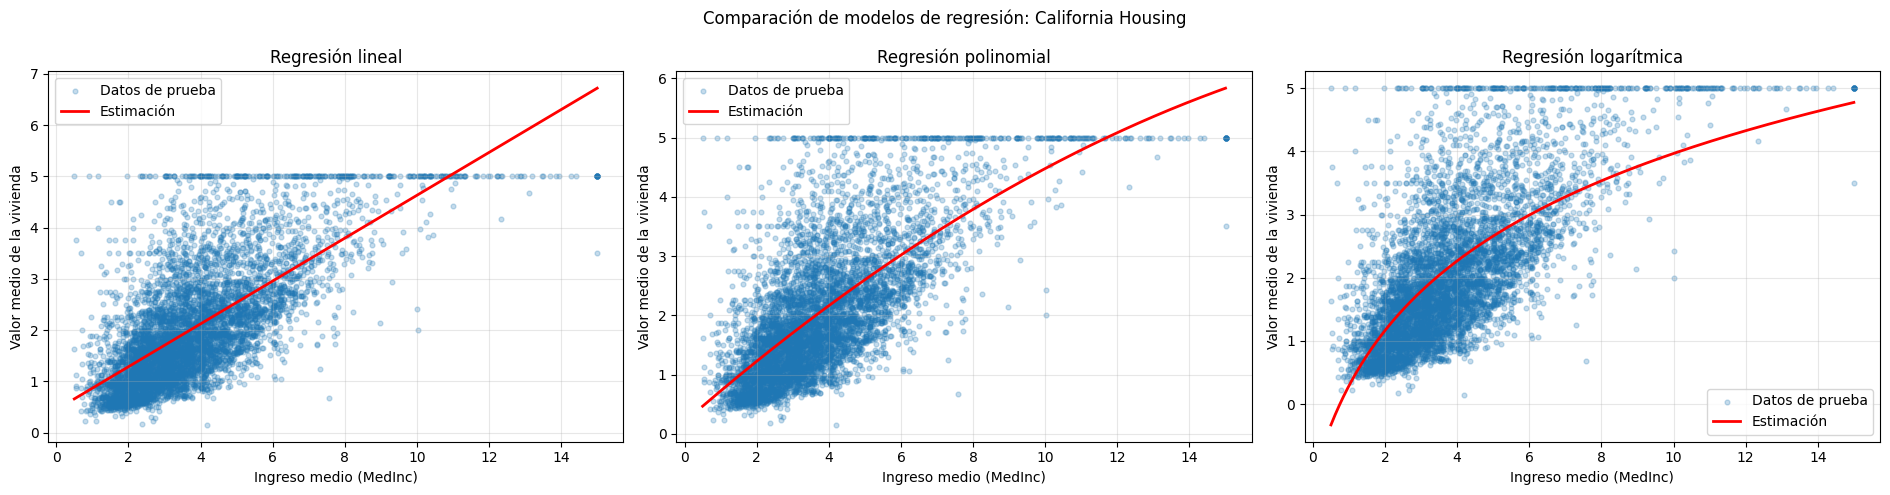

In [7]:

# Cargar California Housing
housing = fetch_california_housing(as_frame=True)
df_housing = housing.frame

# Una variable predictora para visualizar las líneas de estimación
X_reg = df_housing[["MedInc"]]
y_reg = df_housing["MedHouseVal"]

Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    X_reg, y_reg, test_size=0.30, random_state=42
)

modelos_reg = {
    "Regresión lineal": Pipeline([
        ("modelo", LinearRegression())
    ]),
    "Regresión polinomial": Pipeline([
        ("polinomio", PolynomialFeatures(degree=2, include_bias=False)),
        ("modelo", LinearRegression())
    ]),
    "Regresión logarítmica": Pipeline([
        ("logaritmo", FunctionTransformer(np.log1p, validate=True)),
        ("modelo", LinearRegression())
    ])
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)
resultados_reg = []
predicciones_reg = {}

for nombre, modelo in modelos_reg.items():
    modelo.fit(Xr_train, yr_train)
    pred = modelo.predict(Xr_test)
    predicciones_reg[nombre] = pred

    cv_result = cross_validate(
        modelo,
        X_reg,
        y_reg,
        cv=cv,
        scoring={
            "MAE": "neg_mean_absolute_error",
            "RMSE": "neg_root_mean_squared_error",
            "R2": "r2"
        }
    )

    resultados_reg.append({
        "Modelo": nombre,
        "MAE prueba": mean_absolute_error(yr_test, pred),
        "RMSE prueba": mean_squared_error(yr_test, pred) ** 0.5,
        "R2 prueba": r2_score(yr_test, pred),
        "MAE CV": -cv_result["test_MAE"].mean(),
        "RMSE CV": -cv_result["test_RMSE"].mean(),
        "R2 CV": cv_result["test_R2"].mean()
    })

metricas_reg = pd.DataFrame(resultados_reg).set_index("Modelo")
display(metricas_reg.round(4))

# Líneas de estimación
x_linea = np.linspace(
    X_reg["MedInc"].min(),
    X_reg["MedInc"].max(),
    500
).reshape(-1, 1)

fig, axes = plt.subplots(1, 3, figsize=(19, 5))

for ax, (nombre, modelo) in zip(axes, modelos_reg.items()):
    ax.scatter(
        Xr_test["MedInc"],
        yr_test,
        alpha=0.25,
        s=12,
        label="Datos de prueba"
    )
    ax.plot(
        x_linea,
        modelo.predict(x_linea),
        color="red",
        linewidth=2,
        label="Estimación"
    )
    ax.set_title(nombre)
    ax.set_xlabel("Ingreso medio (MedInc)")
    ax.set_ylabel("Valor medio de la vivienda")
    ax.grid(alpha=0.3)
    ax.legend()

plt.suptitle("Comparación de modelos de regresión: California Housing")
plt.tight_layout()
plt.show()

Desarrollar clasificadores para las DB: MNIST Digits, MNIST Fashion, Wine Dataset, Breast Cancer

In [ ]:
# -----------------------------
# Cargar bases de datos
# -----------------------------
datasets = {
    "MNIST Digits": load_digits(),
    "MNIST Fashion": fetch_openml(
        "Fashion-MNIST", version=1, as_frame=False, parser="auto", cache=True
    ),
    "Wine Dataset": load_wine(),
    "Breast Cancer": load_breast_cancer()
}

# Modelos a comparar
modelos = {
    "LDA": Pipeline([
        ("escalado", StandardScaler()),
        ("modelo", LinearDiscriminantAnalysis())
    ]),
    "k-NN": Pipeline([
        ("escalado", StandardScaler()),
        ("modelo", KNeighborsClassifier(n_neighbors=3))
    ]),
    "Árbol de decisión": DecisionTreeClassifier(
        random_state=42
    )
}

resultados = []

# -----------------------------
# Entrenamiento y evaluación
# -----------------------------
for nombre_db, dataset in datasets.items():
    X = dataset.data.astype(np.float32)
    y = dataset.target.astype(int)

    # Para Fashion-MNIST se toma una muestra para mantener tiempos de ejecución razonables
    if nombre_db == "MNIST Fashion":
        rng = np.random.RandomState(42)
        idx = rng.choice(len(X), 10000, replace=False)
        X, y = X[idx], y[idx]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.30,
        random_state=42,
        stratify=y
    )

    for nombre_modelo, modelo in modelos.items():
        modelo.fit(X_train, y_train)
        pred = modelo.predict(X_test)

        resultados.append({
            "Base de datos": nombre_db,
            "Clasificador": nombre_modelo,
            "Exactitud": accuracy_score(y_test, pred),
            "Precisión macro": precision_score(y_test, pred, average="macro", zero_division=0),
            "Recall macro": recall_score(y_test, pred, average="macro", zero_division=0),
            "F1 macro": f1_score(y_test, pred, average="macro", zero_division=0)
        })

        print(f"\n{'=' * 60}")
        print(f"{nombre_db} | {nombre_modelo}")
        print(f"{'=' * 60}")
        print(f"Exactitud: {accuracy_score(y_test, pred):.4f}")
        print(f"Precisión macro: {precision_score(y_test, pred, average='macro', zero_division=0):.4f}")
        print(f"Recall macro: {recall_score(y_test, pred, average='macro', zero_division=0):.4f}")
        print(f"F1 macro: {f1_score(y_test, pred, average='macro', zero_division=0):.4f}")

# -----------------------------
# Resumen comparativo
# -----------------------------
metricas = pd.DataFrame(resultados)

display(
    metricas.pivot_table(
        index="Base de datos",
        columns="Clasificador",
        values=["Exactitud", "Precisión macro", "Recall macro", "F1 macro"],
        aggfunc="first"
    ).round(4)
)


MNIST Digits | LDA
Exactitud: 0.9519
Precisión macro: 0.9522
Recall macro: 0.9516
F1 macro: 0.9517

MNIST Digits | k-NN
Exactitud: 0.9722
Precisión macro: 0.9727
Recall macro: 0.9720
F1 macro: 0.9719

MNIST Digits | Árbol de decisión
Exactitud: 0.8519
Precisión macro: 0.8557
Recall macro: 0.8518
F1 macro: 0.8522

MNIST Fashion | LDA
Exactitud: 0.8043
Precisión macro: 0.8102
Recall macro: 0.8046
F1 macro: 0.8068

MNIST Fashion | k-NN
Exactitud: 0.8033
Precisión macro: 0.8110
Recall macro: 0.8037
F1 macro: 0.8046

MNIST Fashion | Árbol de decisión
Exactitud: 0.7523
Precisión macro: 0.7531
Recall macro: 0.7522
F1 macro: 0.7524

Wine Dataset | LDA
Exactitud: 0.9815
Precisión macro: 0.9825
Recall macro: 0.9841
F1 macro: 0.9829

Wine Dataset | k-NN
Exactitud: 0.9444
Precisión macro: 0.9432
Recall macro: 0.9524
F1 macro: 0.9445

Wine Dataset | Árbol de decisión
Exactitud: 0.9630
Precisión macro: 0.9710
Recall macro: 0.9593
F1 macro: 0.9638

Breast Cancer | LDA
Exactitud: 0.9357
Precisión mac

Exactitud                           F1 macro          \
Clasificador        LDA    k-NN Árbol de decisión      LDA    k-NN   
Base de datos                                                        
Breast Cancer    0.9357  0.9532            0.9181   0.9291  0.9486   
MNIST Digits     0.9519  0.9722            0.8519   0.9517  0.9719   
MNIST Fashion    0.8043  0.8033            0.7523   0.8068  0.8046   
Wine Dataset     0.9815  0.9444            0.9630   0.9829  0.9445   

                                Precisión macro                            \
Clasificador  Árbol de decisión             LDA    k-NN Árbol de decisión   
Base de datos                                                               
Breast Cancer            0.9126          0.9478  0.9652            0.9126   
MNIST Digits             0.8522          0.9522  0.9727            0.8557   
MNIST Fashion            0.7524          0.8102  0.8110            0.7531   
Wine Dataset             0.9638          0.9825  0.9432            0.9710   

              Recall macro                            
Clasificador           LDA    k-NN Árbol de decisión  
Base de datos                                         
Breast Cancer       0.9172  0.9375            0.9126  
MNIST Digits        0.9516  0.9720            0.8518  
MNIST Fashion       0.8046  0.8037            0.7522  
Wine Dataset        0.9841  0.9524            0.9593